# Example: Single spin Part 2: Gradient descent gate optimization

First, we make the necessary imports.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cthree.optimisation_map import OptimisationMap
from cthree.quantity import Quantity
from cthree.measurement.unitary_fidelity import UnitaryFidelity
from cthree.model.closed_system import ClosedSystem
from cthree.model.drive_operator import DriveOperator
from cthree.model.qubit import Qubit
from cthree.optimisers.scipy_optimiser import ScipyOptimiser
from cthree.optimisers.scipy_optimiser_gradient import ScipyOptimiserGradient
from cthree.propagation.scipy_expm_goat import ScipyExpmGOAT
from cthree.signal.envelopes import ConstantEnvelope
from cthree.signal.iq_mixer import IQMixer

For signal generation, we define a simple cosine shaped tone generator $A \cos(\omega t)$

In [2]:
t_final = 10e-9
tone = ConstantEnvelope()
tone.t_final.set_value(t_final)
gen = IQMixer(envelopes=[tone])

We can inspect the pre-defined parameters with

In [3]:
params = gen.get_parameters()

in this case amplitude $A$ and frequency $\omega$ and phase $\phi$.

Next, we setup the qubit system we want to control. We set the qubit frequency $\omega_q$ to be 4.8 GHz and define the Hamiltonian as $$H(t)=H_\text{drift}+H_c(t)= \frac{\omega_q}{2} \sigma_z + \Omega(t)\sigma_x$$, where $\Omega(t)=A\cos(\omega t+\phi)$ will be supplied by the generator.

In [4]:
FREQ = 4.327884e9 * 2 * np.pi

drive = DriveOperator(gen, isLongitudinal=False)
controlled_qubit = Qubit(
    frequency=Quantity(
        FREQ,
        min_value=FREQ / 4,
        max_value=FREQ,
        unit="Hz",
        name="Qubit frequency",
    ),
    drives=[drive],
)

model = ClosedSystem(controlled_qubit)

Textbook values for implementing an $X$ rotation on this system at a time $T$ would be $\omega=\omega_q$ and $A=\pi/T$. We use some offset from these values as initial guess to demonstrate the optimization procedure.

In [5]:
params[0].set_value(0.5 * np.pi / t_final)
params[2].set_value(1.01 * FREQ)

We select a propagation method, piecewise constant exponentation, and configure $\sigma_x$ as a target gate. Also we initialize the full basis at time 0 with $\mathcal{I}_2$

In [6]:
prop = ScipyExpmGOAT(model, res=500e9)

X = np.array([[0.0, 1], [1, 0.0]])
Y = np.array([[0.0, -1j], [1j, 0.0]])
Z = np.array([[1, 0], [0.0, -1]])

prop.set_initial_state(np.identity(2))
gateFid = UnitaryFidelity(
    propagation=prop,
    gate=X,
    times=np.array([0.0, t_final]),
)

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Population'>], dtype=object))

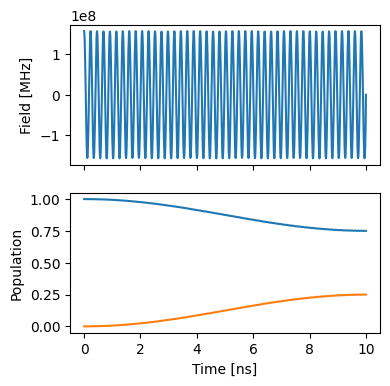

In [7]:
def plotStates():
    """Plot the states."""
    ts = np.linspace(0, t_final, 1001)
    states = prop.propagate(ts)
    sig = gen.generate_signal(ts)

    fig, ax = plt.subplots(2, figsize=(4, 4), sharex=True)
    ax[0].plot(ts / 1e-9, sig)
    ax[0].set_ylabel("Field [MHz]")
    ax[1].plot(ts / 1e-9, np.abs(states)[:, :, 0] ** 2)
    ax[1].set_ylabel("Population")
    ax[-1].set_xlabel("Time [ns]")
    return fig, ax


plotStates()

As expected, we get a partial transfer and a low fidelity.

In [8]:
gateFid.measure()

np.float64(0.09555411208408474)

We define an optimizer and link our fidelity measure as a goal function and the parameters of the cosine tone and optimise just amplitude and frequency, as in the state transfer example.

In [9]:
optmap = OptimisationMap()
optmap.add(gen, [params[0], params[2]])
opt = ScipyOptimiserGradient(gateFid, optimisables=optmap)

In [10]:
opt.optimise()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.04446D-01    |proj g|=  1.44671D+00

At iterate    1    f=  8.83426D-01    |proj g|=  5.37267D-01

At iterate    2    f=  8.82372D-01    |proj g|=  5.33935D-01

At iterate    3    f=  8.80871D-01    |proj g|=  5.63917D-01

At iterate    4    f=  8.75056D-01    |proj g|=  5.66274D-01

At iterate    5    f=  8.64322D-01    |proj g|=  5.68469D-01

At iterate    6    f=  8.42535D-01    |proj g|=  5.69410D-01

At iterate    7    f=  8.14676D-01    |proj g|=  5.65820D-01

At iterate    8    f=  8.04354D-01    |proj g|=  6.16619D-02

At iterate    9    f=  8.03722D-01    |proj g|=  4.59836D-02

At iterate   10    f=  8.03720D-01    |proj g|=  3.63706D-03

At iterate   11    f=  8.03720D-01    |proj g|=  4.53307D-05

At iterate   12    f=  8.03720D-01    |proj g|=  6.58545D-08

           * * *

Tit   = 

{'status': 1, 'value': np.float64(0.8037201693294314), 'iterations': 17, 'message': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'}

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Population'>], dtype=object))

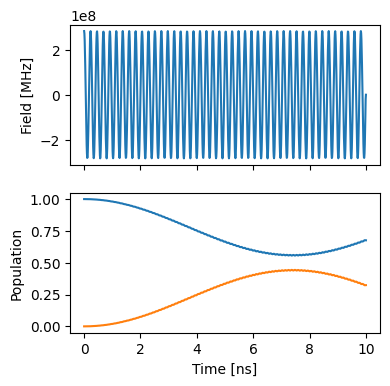

In [11]:
plotStates()

Here, we end up with an unsatisfactory result. For optimising gate fidelities, looking at state populations does not give enough information to identify the problem.

In [12]:
def expecationValue(Op, states):
    """Get the expectation value across states."""
    ex = []
    for state in states:
        ex.append(np.real(state.conj() @ Op @ state.T))
    return ex

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Expectation value $\\langle\\hat\\sigma_i\\rangle$'>],
       dtype=object))

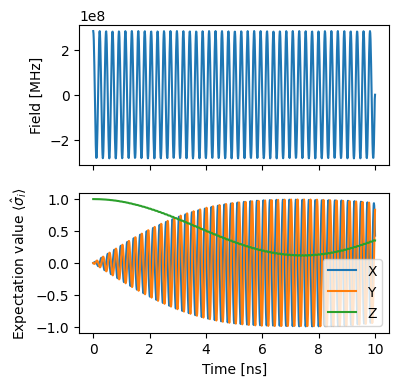

In [13]:
def plotPauli():
    """Plot the Pauli operators."""
    ts = np.linspace(0, t_final, 1001)
    states = prop.propagate(ts)
    sig = gen.generate_signal(ts)

    fig, ax = plt.subplots(2, figsize=(4, 4), sharex=True)
    ax[0].plot(ts / 1e-9, sig)
    ax[0].set_ylabel("Field [MHz]")
    ax[1].plot(ts / 1e-9, expecationValue(X, states[:, :, 0]))
    ax[1].plot(ts / 1e-9, expecationValue(Y, states[:, :, 0]))
    ax[1].plot(ts / 1e-9, expecationValue(Z, states[:, :, 0]))
    ax[1].set_ylabel(r"Expectation value $\langle\hat\sigma_i\rangle$")
    ax[-1].set_xlabel("Time [ns]")
    ax[1].legend(["X", "Y", "Z"])
    return fig, ax


plotPauli()

Instead, we look at the expecation values of the three Pauli operators and observe that the qubit is rotating at its eigenfrequency along the Z-axis. We can mitigate this problem by allowing the rotation axis of our drive to shift and inclide the phase parameter in the optimisation.

In [19]:
optmap = OptimisationMap()
optmap.add(tone, [params[0], params[2], params[3]])
opt = ScipyOptimiser(gateFid, optimisables=optmap)

In [20]:
params[0].set_value(0.5 * np.pi / t_final)
params[2].set_value(1.01 * FREQ)
opt.optimise()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.04446D-01    |proj g|=  1.44671D+00

At iterate    1    f=  8.80807D-01    |proj g|=  5.50524D-01

At iterate    2    f=  8.78773D-01    |proj g|=  5.49220D-01

At iterate    3    f=  8.72586D-01    |proj g|=  5.64890D-01

At iterate    4    f=  8.55109D-01    |proj g|=  5.67274D-01

At iterate    5    f=  8.14049D-01    |proj g|=  5.68315D-01

At iterate    6    f=  7.26510D-01    |proj g|=  5.62986D-01

At iterate    7    f=  5.58043D-01    |proj g|=  1.02734D+00

At iterate    8    f=  3.79687D-01    |proj g|=  8.45813D-01

At iterate    9    f=  2.91223D-01    |proj g|=  1.48047D+00

At iterate   10    f=  2.38456D-01    |proj g|=  7.38246D-01

At iterate   11    f=  2.35813D-01    |proj g|=  7.44981D-01

At iterate   12    f=  2.32785D-01    |proj g|=  1.09379D+00

At iterate   13    f=  2.1

{'status': 1, 'value': np.float64(1.3113954366872349e-11), 'iterations': 108, 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'}


           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     21     27     22     0     0   1.559D-05   1.311D-11
  F =   1.3113954366872349E-011

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Expectation value $\\langle\\hat\\sigma_i\\rangle$'>],
       dtype=object))

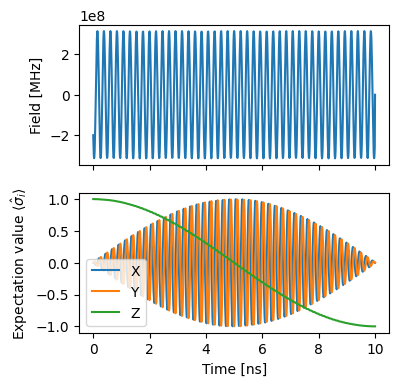

In [21]:
plotPauli()